In [354]:
import cv2
# to install cv2 use: pip install opencv-python
import matplotlib.pyplot as plt 
import numpy as np

(648, 702)


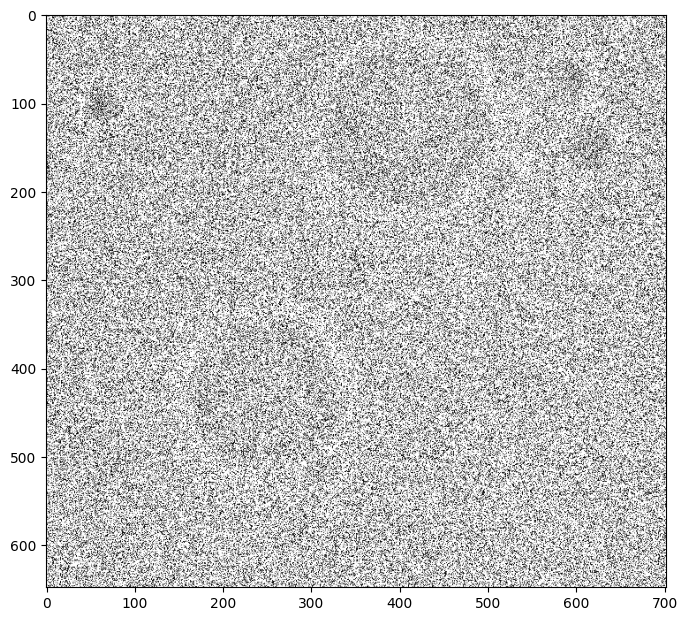

In [355]:
fname = 'Circles-noisy.png'
img = cv2.imread(fname,cv2.IMREAD_GRAYSCALE)
W,H=img.shape
print(img.shape)
ratio=H/W
fig = plt.figure(figsize=(8,8*ratio))
plt.imshow(img, cmap='gray')

In [356]:
# OpenCV Gaussian Blur 
m = 9
dImg_GaussianBlur = cv2.GaussianBlur(img,(m,m),0)

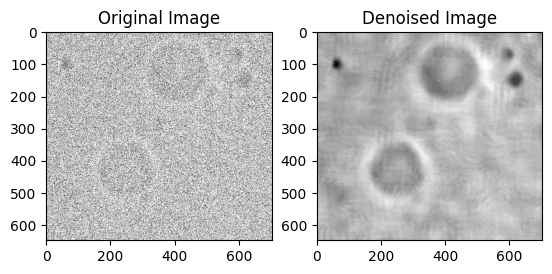

In [357]:
dst = cv2.fastNlMeansDenoising(dImg_GaussianBlur, None, h=21, templateWindowSize=27, searchWindowSize=51)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.subplot(122), plt.imshow(dst, cmap='gray')
plt.title('Denoised Image')
plt.show()

In [358]:
# correlate
def correlate (kernel, image):
    W = image.shape[0]
    H = image.shape[1]
    out =np.zeros((W,H))
    a = kernel.shape[0]%2
    b = kernel.shape[1]%2
    #print (a,b)
    for y in range(b,H-b): 
        for x in range(a,W-a): 
            for s in range (-a,a+1):
                for t in range (-b, b+1):
                    out[x,y] += (kernel[s,t]*image[x+s,y+t])
    return out

In [359]:
def rescale (image):
    image = np.absolute(image)
    mymin=np.amin(image)
    mymax=np.amax(image)
    W = image.shape[0]
    H = image.shape[1]
    for y in range(H): 
        for x in range(W): 
            image[x,y] = (image[x,y]-mymin)*256/(mymax-mymin)
    return image

In [360]:
Laplace = np.array([[-1,-1,-1], [-1, 8, -1],[-1,-1,-1]], dtype=float)
#print(Laplace)

In [361]:
dImg = correlate (Laplace, dst)
dImg = rescale (dImg)

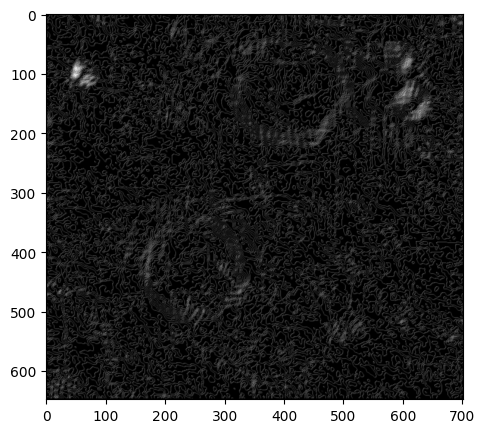

In [362]:
fig = plt.figure(figsize=(15,5))
plt.imshow(dImg, cmap='gray')

In [363]:
# sharpen edges
eImg = 0.1*dImg + 0.9*dst

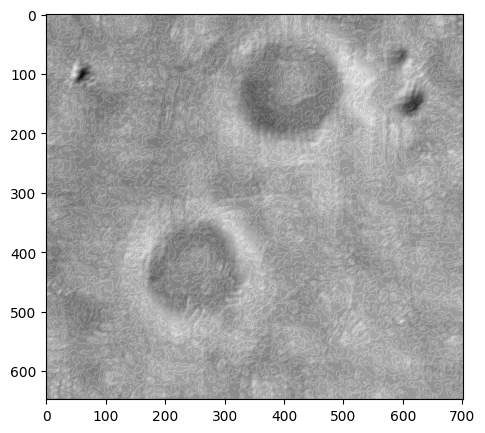

In [364]:
fig = plt.figure(figsize=(15,5))
plt.imshow(eImg, cmap='gray')

(Text(0.5, 1.0, 'Canny'), ([], []), ([], []))

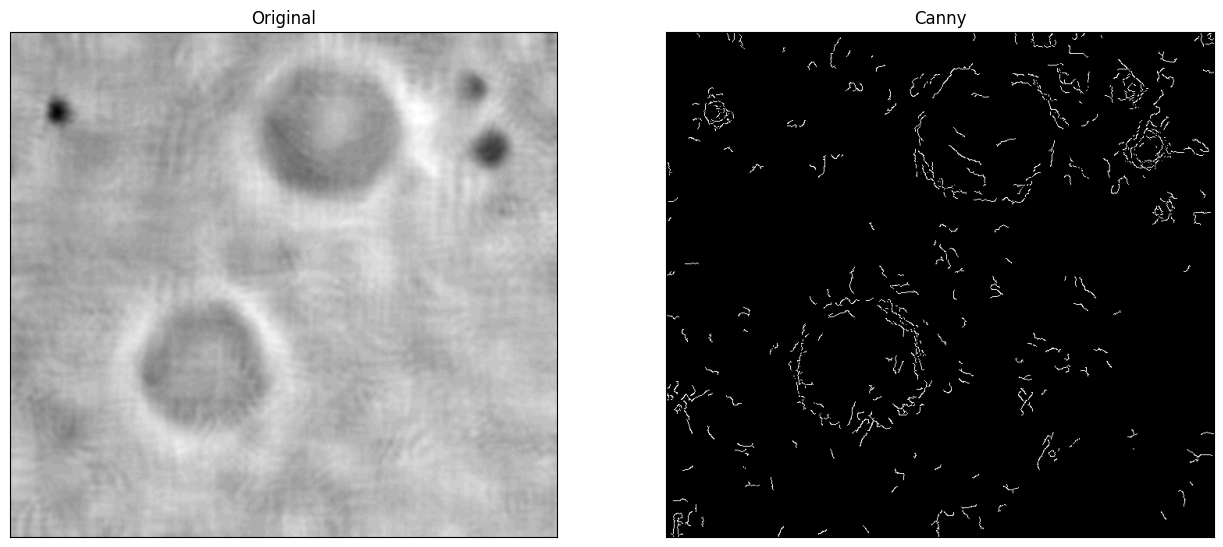

In [ ]:
img_norm = cv2.normalize(dst, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

blur = cv2.GaussianBlur(img_norm,(5,5),0)

# 2nd parameter is the minVal for non-edges
# 3rd parameter is the maxVal for sure-edges
edges = cv2.Canny(blur,20,40)

fig = plt.figure(figsize=(24,8))
plt.subplot(1,3,1),plt.imshow(dst,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,2),plt.imshow(edges,cmap = 'gray')
plt.title('Canny'), plt.xticks([]), plt.yticks([])
